# Random-sample-imputation

In [159]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [161]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [162]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [163]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [164]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [166]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [167]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [168]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


In [169]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

29    NaN
55    NaN
533   NaN
495   NaN
468   NaN
       ..
330   NaN
214   NaN
466   NaN
121   NaN
270   NaN
Name: Age_imputed, Length: 140, dtype: float64

In [170]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([26. , 53. , 56. , 31. , 33. , 39. , 39. , 50. , 30. , 65. , 36. ,
       25. , 27. , 24. , 28. , 16. , 20. , 21. , 30. , 25. , 39. ,  7. ,
       33. , 46. , 44. , 34. , 30. , 28. , 49. , 24. , 40. , 41. , 26. ,
       28. , 25. ,  4. , 22. , 21. , 39. , 22. , 32. , 25. , 61. , 60. ,
       21. , 49. , 29. , 34. ,  1. ,  3. , 28. , 15. , 45. , 22. , 38. ,
       44. , 24. , 28. ,  1. , 36. , 17. , 32. , 28. ,  9. , 19. , 33. ,
       20. , 40.5, 24. , 48. , 40. ,  9. , 36. , 45. ,  2. , 62. , 34. ,
       25. , 45. , 17. , 42. , 36. , 24. , 18. , 31. , 18. , 34. , 52. ,
       29. , 22. , 24. , 14. , 21. , 48. , 58. , 24. , 28. , 59. , 38. ,
       36. , 30. , 36. , 45. ,  1. , 19. ,  2. , 24. , 21. , 14. , 32. ,
       24. , 14. ,  4. , 28. , 27. , 32. , 27. , 18. , 26. , 37. , 22. ,
       18. , 11. , 48. ,  4. , 33. , 25. , 18. , 30. , 20. , 42. , 33. ,
       22. , 26. , 13. , 22. , 39. , 21. , 50. , 16. ])

In [171]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_test['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

In [172]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,17.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


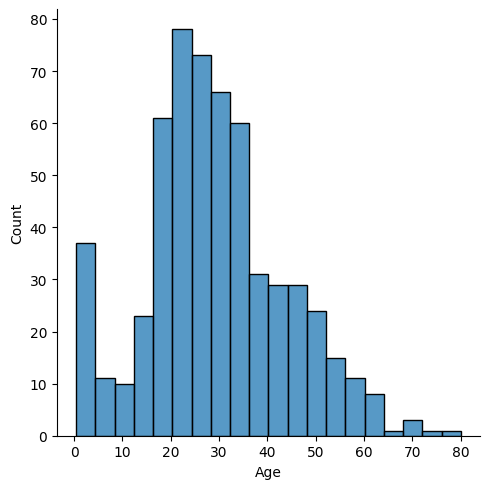

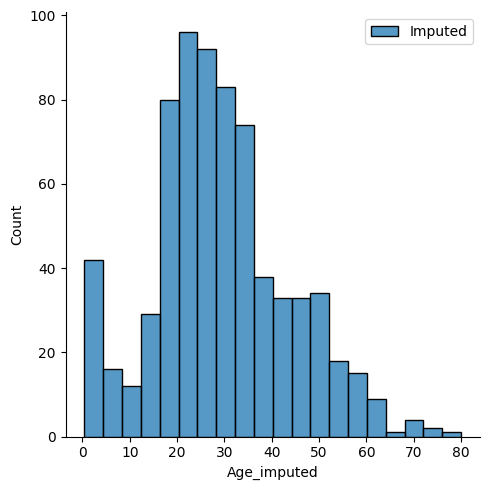

In [173]:
sns.displot(X_train['Age'], label='Original')
sns.displot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

C:\Users\jadha\AppData\Local\Temp\ipykernel_3544\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\jadha\AppData\Local\Temp\ipykernel_3544\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

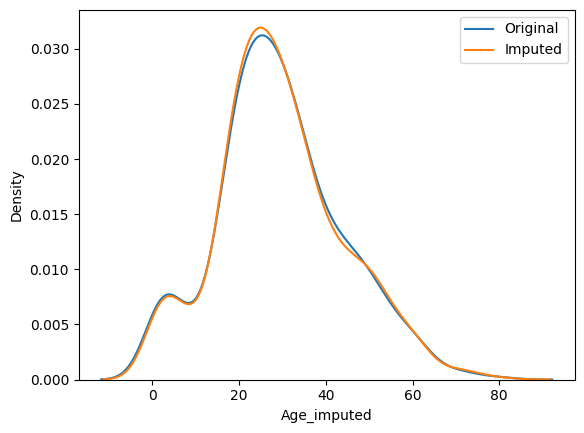

In [174]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [175]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  210.2517072477435
Variance after random imputation:  209.22701466442265


In [176]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,69.134875
Age,71.580633,210.251707,210.251707
Age_imputed,69.134875,210.251707,209.227015


<Axes: >

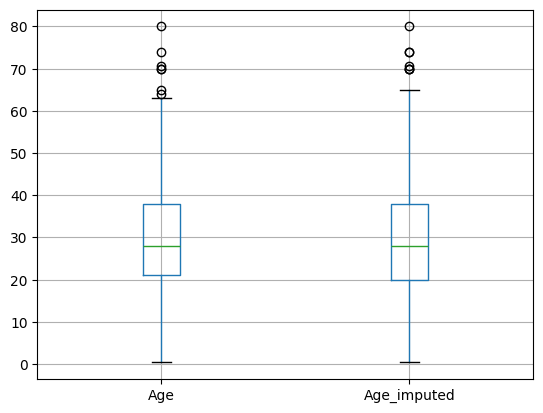

In [177]:
X_train[['Age', 'Age_imputed']].boxplot()

In [178]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [179]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [180]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [181]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [182]:
X = data
y = data['SalePrice']

In [183]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [184]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [185]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
147,Gd,TA,222500,TA,Gd
433,TA,TA,181000,TA,TA
510,TA,TA,164900,TA,TA
124,TA,TA,181000,TA,TA
1262,TA,TA,161500,TA,TA


In [186]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [187]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
123,NaN,TA,153900,TA,Gd
392,NaN,TA,106500,TA,Gd
1024,Gd,TA,287000,TA,Gd
466,Po,TA,167000,TA,Po
26,NaN,TA,134800,TA,Gd


In [188]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [189]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.035959
Gd,0.009973,0.010274
Po,0.000907,0.001712
Ex,0.000907,0.000856


In [190]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.649832
TA,0.412439,0.542088
Fa,0.040917,0.050505
Po,0.027823,0.035915
Ex,0.024550,0.032548


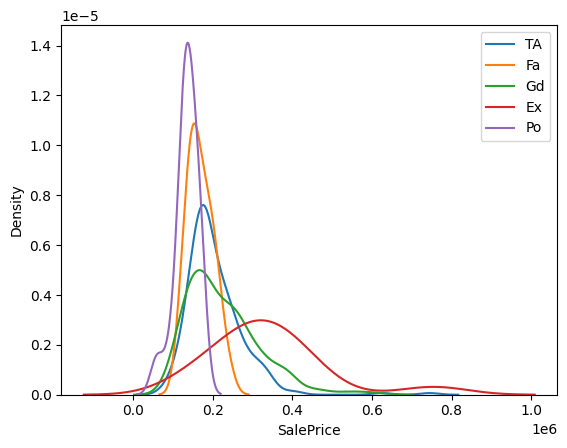

In [191]:
for category in X_train['FireplaceQu'].dropna().unique():
    subset = X_train.loc[X_train['FireplaceQu'] == category, 'SalePrice']
    sns.kdeplot(subset, label=category)

plt.legend()
plt.show()

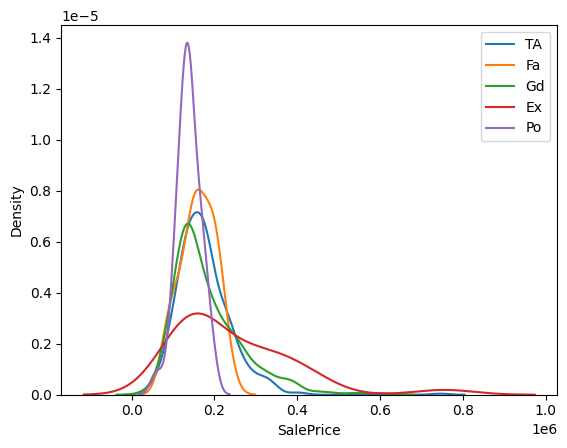

In [192]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    subset = X_train.loc[X_train['FireplaceQu_imputed'] == category, 'SalePrice']
    sns.kdeplot(subset, label=category)

plt.legend()
plt.show()